# 03 · M3 Bidirectional GRU

**Owner:** Ishaan Karmokar  
Script: `src/models/m3_bigru.py`. Fixed configuration (no metaheuristic search), RMSprop, 3 seeds.

In [1]:
# Setup: works locally (run from notebooks/) and on Google Colab.
# On Colab, first clone the team repository and install the requirements:
#   !git clone <repo-url> ecg-arrhythmia && %cd ecg-arrhythmia/notebooks
#   !pip install -q -r ../requirements.txt
import os, sys, json
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
ROOT = os.path.abspath('..')
sys.path[:0] = [os.path.join(ROOT, 'src'), os.path.join(ROOT, 'src', 'models')]
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'serif', 'font.serif': ['Times New Roman', 'DejaVu Serif']})
%matplotlib inline

In [2]:
from m3_bigru import build, CONFIG
CFG, TAG = CONFIG, "m3_bigru"
print(CFG)
build(CFG).summary()

{'lr': 0.001, 'pool': 3, 'units': 32, 'dropout': 0.3, 'dense': 64}


Model: "bigru"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ beat (InputLayer)   │ (None, 360, 1)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling1d   │ (None, 120, 1)    │          0 │ beat[0][0]        │
│ (AveragePooling1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 120, 64)   │      6,720 │ average_pooling1… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 64)        │     18,816 │ bidirectional[0]… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rr (InputLayer)     │ (None, 4)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 68)        │          0 │ bidirectional_1[… │
│ (Concatenate)       │                   │            │ rr[0][0]          │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      4,416 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 5)         │        325 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 30,277 (118.27 KB)

 Trainable params: 30,277 (118.27 KB)

 Non-trainable params: 0 (0.00 B)

In [3]:
# Re-score the saved weights of every seed on DS2 and check they reproduce the
# numbers stored in results/ by the training script.
from deep_common import load_data, load_trained, predict
from evaluate import score
from config import SEEDS, CLASSES
data = load_data()
Xte, Fte, yte = data['test']
rows = []
for seed in SEEDS:
    model = load_trained(build, CFG, TAG, seed)
    m = score(yte, predict(model, Xte, Fte))
    with open(os.path.join(ROOT, 'results', 'runs', f'{TAG}_seed{seed}.json')) as fh:
        saved = json.load(fh)
    rows.append((seed, m['accuracy'], m['macro_f1'], m['macro_f1_nsvf'],
                 abs(m['macro_f1'] - saved['macro_f1']) < 1e-9))
print('seed  accuracy  macro-F1  macro-F1(NSVF)  matches saved')
for r in rows:
    print(f'{r[0]:4d}  {r[1]:.4f}    {r[2]:.4f}    {r[3]:.4f}          {r[4]}')

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
2026-10-04 19:03:28.622488: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node Parall

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
2026-10-04 19:03:37.584979: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node Parall

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
2026-10-04 19:03:48.754972: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node Parall

seed  accuracy  macro-F1  macro-F1(NSVF)  matches saved
  42  0.8970    0.3239    0.4049          True
  43  0.8900    0.3286    0.4108          True
  44  0.8854    0.3465    0.4331          True


DS2 macro-F1 0.3330 +/- 0.0097 (N/S/V/F: 0.4163 +/- 0.0122)
class   recall           F1
  N    0.939 ± 0.008    0.946 ± 0.003   (n=44228)
  S    0.026 ± 0.022    0.040 ± 0.032   (n=1836)
  V    0.827 ± 0.032    0.674 ± 0.018   (n=3220)
  F    0.009 ± 0.005    0.005 ± 0.002   (n=388)
  Q    0.000 ± 0.000    0.000 ± 0.000   (n=7)


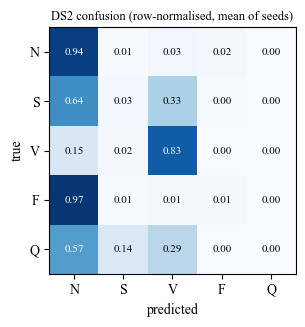

In [4]:
with open(os.path.join(ROOT, 'results', f'{TAG}.json')) as fh:
    agg = json.load(fh)
print(f"DS2 macro-F1 {agg['macro_f1']['mean']:.4f} +/- {agg['macro_f1']['std']:.4f} "
      f"(N/S/V/F: {agg['macro_f1_nsvf']['mean']:.4f} +/- {agg['macro_f1_nsvf']['std']:.4f})")
print('class   recall           F1')
for c in CLASSES:
    r, f = agg['per_class_recall'][c], agg['per_class_f1'][c]
    print(f"  {c}    {r['mean']:.3f} ± {r['std']:.3f}    {f['mean']:.3f} ± {f['std']:.3f}   (n={agg['support'][c]})")
cm = np.array(agg['confusion_matrix_sum']) / len(agg['seeds'])
norm = cm / np.maximum(cm.sum(1, keepdims=True), 1)
fig, ax = plt.subplots(figsize=(3.6, 3.2))
ax.imshow(norm, cmap='Blues', vmin=0, vmax=1)
for i in range(5):
    for j in range(5):
        ax.text(j, i, f'{norm[i,j]:.2f}', ha='center', va='center', fontsize=8,
                color='white' if norm[i,j] > .55 else 'black')
ax.set_xticks(range(5), CLASSES); ax.set_yticks(range(5), CLASSES)
ax.set_xlabel('predicted'); ax.set_ylabel('true')
ax.set_title('DS2 confusion (row-normalised, mean of seeds)', fontsize=9)
plt.show()

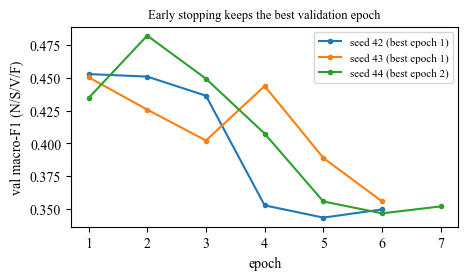

In [5]:
fig, ax = plt.subplots(figsize=(5, 2.6))
for seed in SEEDS:
    with open(os.path.join(ROOT, 'results', 'runs', f'{TAG}_seed{seed}.json')) as fh:
        r = json.load(fh)
    h = r['history']
    ax.plot([e['epoch'] for e in h], [e['val_macro_f1_nsvf'] for e in h], marker='o', ms=3,
            label=f"seed {seed} (best epoch {r['best_epoch']})")
ax.set_xlabel('epoch'); ax.set_ylabel('val macro-F1 (N/S/V/F)'); ax.legend(fontsize=8)
ax.set_title('Early stopping keeps the best validation epoch', fontsize=9)
plt.show()

In [6]:
# Full retraining (3 seeds). Takes 30-60 min on a laptop CPU, a few minutes
# on a Colab GPU. Uncomment to reproduce results/m3_bigru.json from scratch.
# !cd .. && python src/models/m3_bigru.py

# Final phase: grouped cross-validation and final model

None of the three changes (multi-beat context, augmentation, focal loss) raised CV macro-F1 by the required 0.01, so the BiGRU keeps its interim architecture; the gain comes from training on all 22 DS1 patients for the CV-chosen 8 epochs.

All choices below were made on DS1 only, with 4-fold grouped cross-validation over its 22 patients (`src/cv.py`). The final model was trained on all 22 DS1 patients on a Colab GPU and DS2 was scored once.

In [7]:
TAG, INTERIM_TAG = 'm3_bigru', 'm3_bigru'
sel = json.load(open(os.path.join(ROOT, 'results', 'final', TAG, 'selected.json')))
print('selected variant:', sel['variant'], '| epochs:', sel['epochs'])
print('config:', sel['config'])
print('calibration offsets (N,S,V,F,Q):', [round(v, 2) for v in sel['offsets']])
print('\nablation under 4-fold grouped CV on DS1 (macro-F1 over N/S/V/F):')
for l in sel['ablation_log']:
    print(f"  {l['step']:10s} {l['cv_macro_f1_nsvf']:.4f}  {'kept' if l['kept'] else 'rejected'}")

selected variant: baseline | epochs: 8
config: {'lr': 0.001, 'pool': 3, 'units': 32, 'dropout': 0.3, 'dense': 64}
calibration offsets (N,S,V,F,Q): [0.0, 0.75, -0.5, -1.0, 0.0]

ablation under 4-fold grouped CV on DS1 (macro-F1 over N/S/V/F):
  baseline   0.4440  kept
  context    0.4425  rejected
  augment    0.4502  rejected
  focal      0.4533  rejected


### Final weights re-scored on CPU (reproducibility check)

In [8]:
# Rebuild each final model, load its weights and score DS2 on CPU; compare with the stored results.
import numpy as np
from deep_common import load_arrays, predict_proba, scaled_rr
from calibrate import apply as apply_offsets
from evaluate import score
cfg, offsets = sel['config'], np.array(sel['offsets'])
d = load_arrays(cfg.get('input', 'beat'))
tr, te = np.flatnonzero(d['split'] != 'test'), np.flatnonzero(d['split'] == 'test')
_, Fte = scaled_rr(d['F'], tr, te)
print('seed  raw macro-F1  calibrated  matches stored')
for seed in (42, 43, 44):
    m = build(cfg)
    m.load_weights(os.path.join(ROOT, 'saved_models', 'final', f'{TAG}_seed{seed}.weights.h5'))
    p = predict_proba(m, d['X'][te], Fte)
    raw, cal = score(d['y'][te], p.argmax(1)), score(d['y'][te], apply_offsets(p, offsets))
    stored = json.load(open(os.path.join(ROOT, 'results', 'final', 'runs', f'{TAG}_seed{seed}.json')))
    ok = abs(raw['macro_f1'] - stored['raw']['macro_f1']) < 1e-9 and abs(cal['macro_f1'] - stored['calibrated']['macro_f1']) < 1e-9
    print(f"{seed:4d}  {raw['macro_f1']:.4f}        {cal['macro_f1']:.4f}      {ok}")

seed  raw macro-F1  calibrated  matches stored


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
2026-10-04 19:03:59.498985: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node Parall

  42  0.3556        0.3446      True


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
2026-10-04 19:04:09.809354: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node Parall

  43  0.3114        0.3122      True


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
2026-10-04 19:04:20.120377: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node Parall

  44  0.3927        0.3964      True


### Interim vs final on DS2 (mean ± std over 3 seeds)

In [9]:
fin = json.load(open(os.path.join(ROOT, 'results', 'final', f'{TAG}.json')))
old = json.load(open(os.path.join(ROOT, 'results', f'{INTERIM_TAG}.json')))
print(f"interim          macro-F1 {old['macro_f1']['mean']:.3f} ± {old['macro_f1']['std']:.3f}")
for kind in ['raw', 'calibrated']:
    r = fin[kind]
    print(f"final {kind:10s} macro-F1 {r['macro_f1']['mean']:.3f} ± {r['macro_f1']['std']:.3f}  | recall "
          + '  '.join(f"{c} {r['per_class_recall'][c]['mean']:.2f}" for c in 'NSVF'))

interim          macro-F1 0.333 ± 0.010
final raw        macro-F1 0.353 ± 0.033  | recall N 0.85  S 0.29  V 0.87  F 0.07
final calibrated macro-F1 0.351 ± 0.035  | recall N 0.86  S 0.38  V 0.83  F 0.03
